# 🎵 MIDI Music Generator — PyTorch + Embeddings (Local Jupyter)

### What changed
- Notes, offsets, durations are now encoded as **integer indices** (not one-hot)
- Each gets its own **Embedding layer** inside the model — much more efficient
- Lower RAM usage, faster training, better generalisation

### Setup
1. Put your `.mid` files in `midi_data/` next to this notebook
2. Run all cells — models are saved to `midi_data/saved_models/` after training
3. On subsequent runs they load automatically

In [50]:
# Run once to install dependencies
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'music21', 'torch', 'scikit-learn', '-q'])

0

In [51]:
import glob, gc, random, os
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from numpy import argmax

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from music21 import converter, instrument, note, chord, stream

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Configuration

In [52]:
import os

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR = os.getcwd()
MIDI_DIR = os.path.join(BASE_DIR, 'midi_data', '*.mid')
SAVE_DIR = os.path.join(BASE_DIR, 'midi_data', 'saved_models')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'MIDI source : {MIDI_DIR}')
print(f'Models saved: {SAVE_DIR}')

# ── Hyperparameters ────────────────────────────────────────────────────────────
SEGMENT_LENGTH = 32     # sequence length fed to the LSTM
BATCH_SIZE     = 64
LEARNING_RATE  = 1e-3
NUM_EPOCHS     = 150
PATIENCE       = 5
VAL_SPLIT      = 0.2

# ── Embedding dimensions (tune freely) ────────────────────────────────────────
NOTE_EMB_DIM   = 64     # embedding size for notes
OFFSET_EMB_DIM = 32     # embedding size for offsets
DUR_EMB_DIM    = 32     # embedding size for durations
HIDDEN_SIZE    = 256    # LSTM hidden units

# ── Generation ─────────────────────────────────────────────────────────────────
DIVERSITY_NOTE = 0.7
DIVERSITY_OFF  = 0.7
DIVERSITY_DUR  = 0.2
NUM_GENERATE   = 100

# ── Set True to retrain even if saved models exist ────────────────────────────
FORCE_RETRAIN  = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MIDI source : C:\Users\risha\OneDrive\Desktop\d2l\try\midi_data\*.mid
Models saved: C:\Users\risha\OneDrive\Desktop\d2l\try\midi_data\saved_models
Device: cuda


## Helper Functions

In [53]:
# ── Data extraction ────────────────────────────────────────────────────────────

def data_extractor(directory):
    """Parse MIDI files → parallel lists of notes, offsets, durations."""
    notes, offsets, durations = [], [], []
    files = glob.glob(directory)
    print(f'Found {len(files)} MIDI file(s)')
    skipped = 0

    for file in files:
        try:
            mid = converter.parse(file)
        except Exception as e:
            print(f'  Skipping {os.path.basename(file)}: {e}')
            skipped += 1
            continue

        prev_offset = 0
        try:
            s2 = instrument.partitionByInstrument(mid)
            notes_to_parse = s2.parts[0].recurse()
        except Exception:
            notes_to_parse = mid.flat.notes

        try:
            for element in notes_to_parse:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))
                    durations.append(str(element.quarterLength))
                    offsets.append(round(float(element.offset - prev_offset), 3))
                    prev_offset = element.offset
                elif isinstance(element, chord.Chord):
                    notes.append('.'.join(str(n) for n in element.normalOrder))
                    durations.append(str(element.quarterLength))
                    offsets.append(round(float(element.offset - prev_offset), 3))
                    prev_offset = element.offset
        except Exception as e:
            print(f'  Skipping {os.path.basename(file)} (parse error): {e}')
            skipped += 1

    print(f'Loaded {len(files) - skipped}/{len(files)} files, extracted {len(notes)} events')
    return [notes, offsets, durations]


# ── Vocabulary helpers ─────────────────────────────────────────────────────────

def build_vocab(data):
    """Return sorted unique list and token→index dict."""
    unique = sorted(set(data))
    tok2idx = {t: i for i, t in enumerate(unique)}
    return unique, tok2idx


def encode(data, tok2idx):
    """Map a list of tokens to a list of integer indices."""
    return [tok2idx[t] for t in data]


def decode(indices, unique):
    """Map integer indices back to tokens."""
    return [unique[i] for i in indices]


# ── Sequence segmentation (integer indices, not one-hot) ───────────────────────

def make_segments(index_array, seq_length=SEGMENT_LENGTH):
    """Slide a window → (X, y) as integer index arrays."""
    input_seq, output_seq = [], []
    for i in range(len(index_array) - seq_length):
        input_seq.append(index_array[i : i + seq_length])
        output_seq.append(index_array[i + seq_length])
    X = np.array(input_seq, dtype=np.int64)   # (N, seq_len)
    y = np.array(output_seq, dtype=np.int64)  # (N,)
    return X, y


# ── Temperature sampling ───────────────────────────────────────────────────────

def sample(logits, temperature=1.0):
    """Sample from logits with temperature scaling."""
    logits = np.asarray(logits, dtype=np.float64)
    logits /= max(temperature, 1e-6)
    probs = np.exp(logits - logits.max())
    probs /= probs.sum()
    return np.random.choice(len(probs), p=probs)


# ── MIDI stream builder ────────────────────────────────────────────────────────

def to_midi(notes_seq, offsets_seq, durations_seq):
    s = stream.Stream()
    offset = offsets_seq[0]
    for i, ele in enumerate(notes_seq):
        try:
            q_len = float(durations_seq[i])
        except (ValueError, TypeError):
            q_len = Fraction(durations_seq[i])
        if str(ele)[0].isalpha():
            n = note.Note(ele)
            n.quarterLength = q_len
            s.insert(offset, n)
        else:
            c = chord.Chord(list(map(int, str(ele).split('.'))))
            c.quarterLength = q_len
            s.insert(offset, c)
        offset += offsets_seq[i]
    return s

print('Helper functions defined ✓')

Helper functions defined ✓


## Model — LSTM with Embedding Layers

In [54]:
class MusicLSTM(nn.Module):
    """
    Embedding → LSTM → Dropout → Linear(128) → Linear(vocab_size)

    Each model handles one stream (notes / offsets / durations).
    The embedding layer learns a dense representation of each token,
    replacing the sparse one-hot vectors used previously.
    """
    def __init__(self, vocab_size, emb_dim, hidden_size=HIDDEN_SIZE, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm      = nn.LSTM(emb_dim, hidden_size, num_layers=2,
                                 batch_first=True, dropout=dropout)
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(hidden_size, 128)
        self.relu      = nn.ReLU()
        self.fc2       = nn.Linear(128, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)  — integer indices
        emb = self.embedding(x)          # → (batch, seq_len, emb_dim)
        out, _ = self.lstm(emb)          # → (batch, seq_len, hidden)
        out = self.dropout(out[:, -1, :])  # last time-step
        out = self.relu(self.fc1(out))
        return self.fc2(out)             # raw logits → (batch, vocab_size)

print('MusicLSTM with embeddings defined ✓')

MusicLSTM with embeddings defined ✓


## Training & Save / Load Logic

In [55]:
def train_model(X_train, y_train, vocab_size, emb_dim, label='model'):
    """Train MusicLSTM with early stopping. Returns (model, history)."""
    split  = int(len(X_train) * (1 - VAL_SPLIT))
    X_tr, X_val = X_train[:split], X_train[split:]
    y_tr, y_val = y_train[:split], y_train[split:]

    tr_dl  = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.long),
                                      torch.tensor(y_tr, dtype=torch.long)),
                        batch_size=BATCH_SIZE, shuffle=True)
    val_dl = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.long),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=BATCH_SIZE)

    model     = MusicLSTM(vocab_size, emb_dim).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history  = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss, patience_counter, best_state = float('inf'), 0, None

    for epoch in range(1, NUM_EPOCHS + 1):
        # Train
        model.train()
        tr_loss = tr_correct = tr_total = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()
            tr_loss    += loss.item() * len(xb)
            tr_correct += (logits.argmax(1) == yb).sum().item()
            tr_total   += len(xb)

        # Validate
        model.eval()
        val_loss = val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss   = criterion(logits, yb)
                val_loss    += loss.item() * len(xb)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total   += len(xb)

        avg_tr  = tr_loss  / tr_total;  tr_acc  = tr_correct  / tr_total
        avg_val = val_loss / val_total; val_acc = val_correct / val_total
        scheduler.step(avg_val)

        history['loss'].append(avg_tr);         history['accuracy'].append(tr_acc)
        history['val_loss'].append(avg_val);    history['val_accuracy'].append(val_acc)

        print(f'[{label}] Epoch {epoch}/{NUM_EPOCHS}  '
              f'loss={avg_tr:.4f}  acc={tr_acc:.4f}  '
              f'val_loss={avg_val:.4f}  val_acc={val_acc:.4f}')

        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    return model, history


def save_model(model, vocab, emb_dim, label):
    path = os.path.join(SAVE_DIR, f'{label}.pt')
    torch.save({'state_dict': model.state_dict(),
                'vocab': vocab,
                'emb_dim': emb_dim}, path)
    print(f'  Saved → {path}')


def load_model(label):
    """Returns (model, vocab, emb_dim) or (None, None, None) if not found."""
    path = os.path.join(SAVE_DIR, f'{label}.pt')
    if not os.path.exists(path):
        return None, None, None
    ckpt      = torch.load(path, map_location=DEVICE)
    vocab     = ckpt['vocab']
    emb_dim   = ckpt['emb_dim']
    model     = MusicLSTM(len(vocab), emb_dim).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    print(f'  Loaded ← {path}')
    return model, vocab, emb_dim

print('Training & save/load functions defined ✓')

Training & save/load functions defined ✓


## Extract Data

In [56]:
print('Extracting MIDI data …')
data          = data_extractor(MIDI_DIR)
note_data     = data[0]
offset_data   = data[1]
duration_data = data[2]

# Build vocabularies
unique_notes,     note_tok2idx = build_vocab(note_data)
unique_offsets,   off_tok2idx  = build_vocab(offset_data)
unique_durations, dur_tok2idx  = build_vocab(duration_data)

unique_note_number     = len(unique_notes)
unique_offset_number   = len(unique_offsets)
unique_duration_number = len(unique_durations)

print(f'Vocab sizes — notes: {unique_note_number}  '
      f'offsets: {unique_offset_number}  '
      f'durations: {unique_duration_number}')

# Encode to integer indices
note_idx = encode(note_data,     note_tok2idx)
off_idx  = encode(offset_data,   off_tok2idx)
dur_idx  = encode(duration_data, dur_tok2idx)

del note_data, offset_data, duration_data
gc.collect()

Extracting MIDI data …
Found 95 MIDI file(s)
  Skipping Bizet Symphony in C 1mov.mid: 2522318709424
  Skipping Bizet Symphony in C 4mov.mid: 2522727995616
  Skipping Buxethude Buxwv138 Prelude.mid: list index out of range
  Skipping Buxethude Buxwv161 Passcaglia.mid: list index out of range
  Skipping Dvorak Symphony op70 n7 1mov.mid: 2522585370928
  Skipping Dvorak Symphony op70 n7 4mov.mid: 2522861986384
  Skipping Kuhlau Sonatina op20 n1.mid: 2522627025264
  Skipping Kuhlau Sonatina op60 n2.mid: 2522344515760
  Skipping Lizt Piano Concerto n1 S124.mid: 2522373025120
  Skipping mendel_op19_2.mid: 2522618493536
Loaded 85/95 files, extracted 44290 events
Vocab sizes — notes: 360  offsets: 48  durations: 35


339232

## Build Segments & Train/Test Split

In [57]:
print('Building segments …')
note_X,   note_y   = make_segments(note_idx)
del note_idx; gc.collect()
offset_X, offset_y = make_segments(off_idx)
del off_idx;  gc.collect()
dur_X,    dur_y    = make_segments(dur_idx)
del dur_idx;  gc.collect()

Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(note_X,   note_y,   test_size=0.2, random_state=42)
Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(offset_X, offset_y, test_size=0.2, random_state=42)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(dur_X,    dur_y,    test_size=0.2, random_state=42)

del note_X, note_y, offset_X, offset_y, dur_X, dur_y
gc.collect()
print(f'Note segs: {len(Xn_tr)} train / {len(Xn_te)} test')
print(f'Offset segs: {len(Xo_tr)} train / {len(Xo_te)} test')
print(f'Duration segs: {len(Xd_tr)} train / {len(Xd_te)} test')

Building segments …
Note segs: 35406 train / 8852 test
Offset segs: 35406 train / 8852 test
Duration segs: 35406 train / 8852 test


## Train or Load Models

If saved models exist in `SAVE_DIR` they load automatically.  
Set `FORCE_RETRAIN = True` in the config cell to train from scratch.

In [58]:
histories = {}

# ── Note model ────────────────────────────────────────────────────────────────
print('\n── Note model ──')
model_notes, loaded_vocab, loaded_emb = load_model('notes')
if model_notes is None or FORCE_RETRAIN:
    model_notes, histories['note'] = train_model(
        Xn_tr, yn_tr, unique_note_number, NOTE_EMB_DIM, label='notes')
    save_model(model_notes, unique_notes, NOTE_EMB_DIM, 'notes')
else:
    unique_notes = loaded_vocab

# ── Offset model ──────────────────────────────────────────────────────────────
print('\n── Offset model ──')
model_offsets, loaded_vocab, loaded_emb = load_model('offsets')
if model_offsets is None or FORCE_RETRAIN:
    model_offsets, histories['offset'] = train_model(
        Xo_tr, yo_tr, unique_offset_number, OFFSET_EMB_DIM, label='offsets')
    save_model(model_offsets, unique_offsets, OFFSET_EMB_DIM, 'offsets')
else:
    unique_offsets = loaded_vocab

# ── Duration model ────────────────────────────────────────────────────────────
print('\n── Duration model ──')
model_durations, loaded_vocab, loaded_emb = load_model('durations')
if model_durations is None or FORCE_RETRAIN:
    model_durations, histories['duration'] = train_model(
        Xd_tr, yd_tr, unique_duration_number, DUR_EMB_DIM, label='durations')
    save_model(model_durations, unique_durations, DUR_EMB_DIM, 'durations')
else:
    unique_durations = loaded_vocab

print('\nAll models ready ✓')


── Note model ──
[notes] Epoch 1/150  loss=4.4329  acc=0.0443  val_loss=4.2751  val_acc=0.0489
[notes] Epoch 2/150  loss=4.1893  acc=0.0553  val_loss=4.1356  val_acc=0.0604
[notes] Epoch 3/150  loss=4.0510  acc=0.0692  val_loss=3.9853  val_acc=0.0726
[notes] Epoch 4/150  loss=4.0040  acc=0.0697  val_loss=3.9550  val_acc=0.0753
[notes] Epoch 5/150  loss=3.8538  acc=0.0823  val_loss=3.8538  val_acc=0.0818
[notes] Epoch 6/150  loss=3.7420  acc=0.0972  val_loss=3.7558  val_acc=0.0976
[notes] Epoch 7/150  loss=3.6406  acc=0.1122  val_loss=3.7044  val_acc=0.1079
[notes] Epoch 8/150  loss=3.5441  acc=0.1263  val_loss=3.6397  val_acc=0.1223
[notes] Epoch 9/150  loss=3.4385  acc=0.1443  val_loss=3.6036  val_acc=0.1370
[notes] Epoch 10/150  loss=3.3390  acc=0.1610  val_loss=3.5601  val_acc=0.1432
[notes] Epoch 11/150  loss=3.2353  acc=0.1843  val_loss=3.4828  val_acc=0.1693
[notes] Epoch 12/150  loss=3.1319  acc=0.2028  val_loss=3.4835  val_acc=0.1738
[notes] Epoch 13/150  loss=3.0333  acc=0.22

C:\Users\risha\AppData\Local\Temp\ipykernel_29804\3292500339.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt      = torch.load(path, map_location=DEVICE)


## Training Curves
*(skipped if models were loaded from cache)*

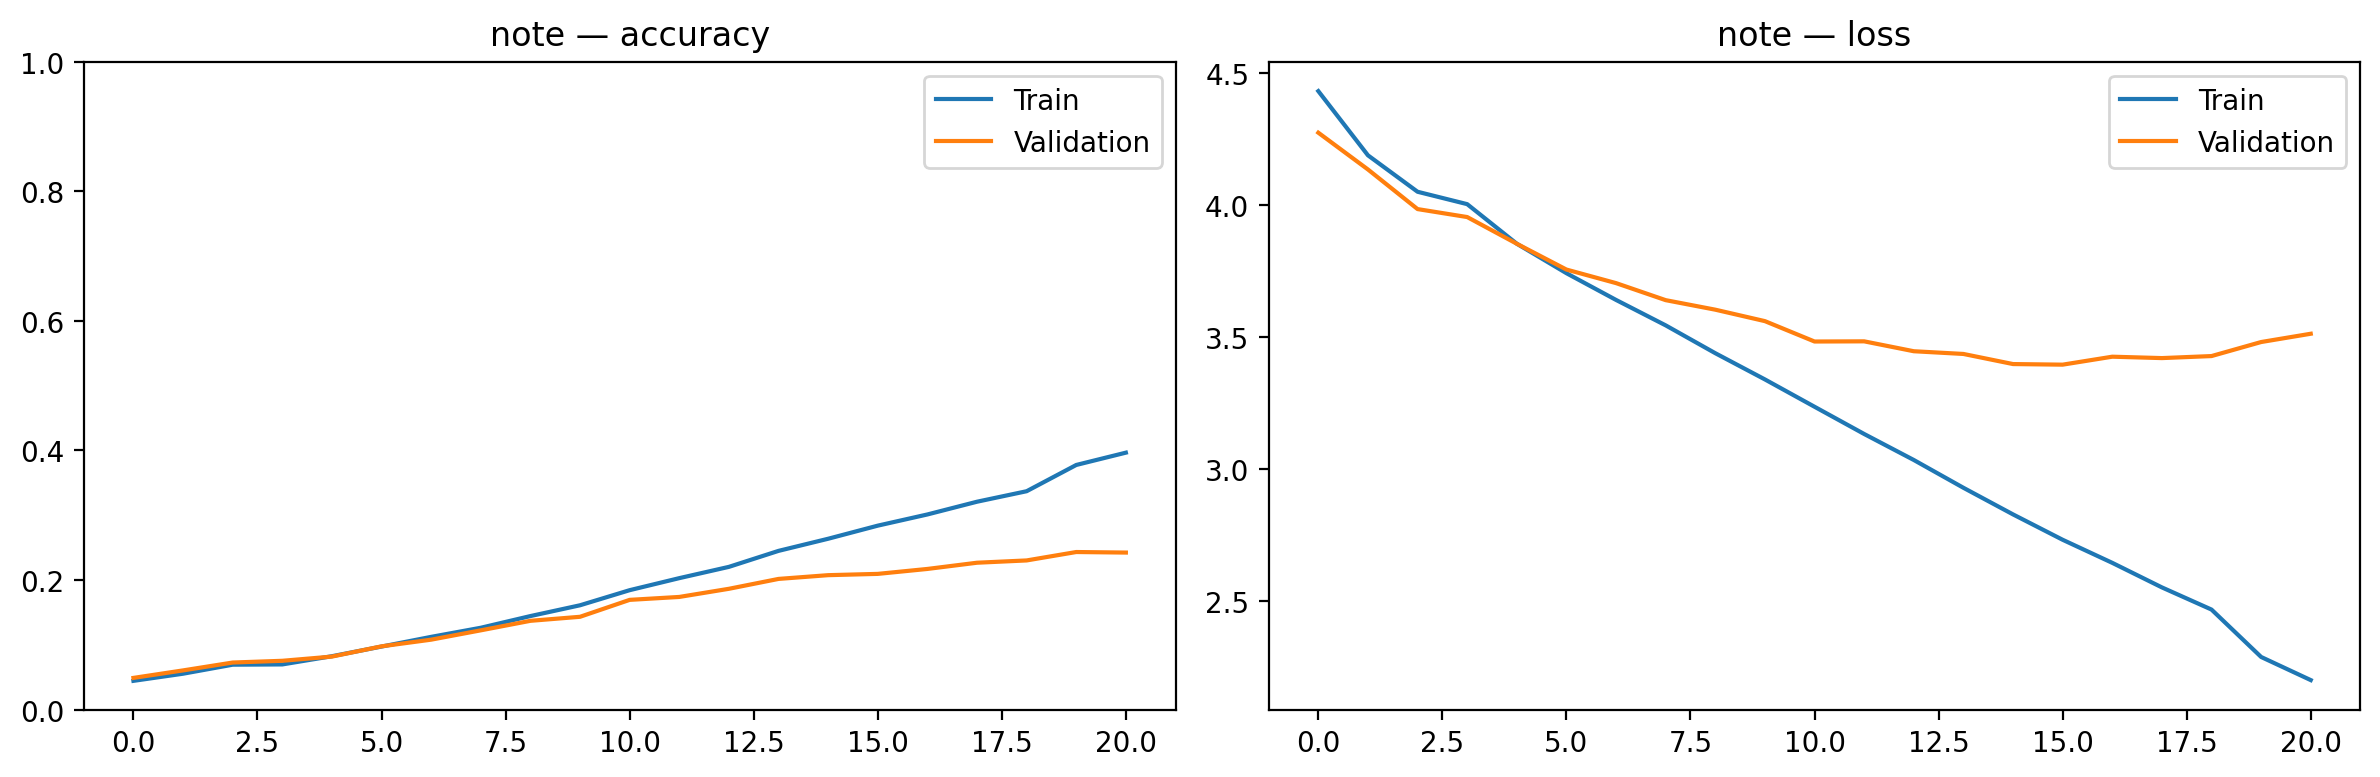

In [59]:
if histories:
    fig, axes = plt.subplots(len(histories), 2, figsize=(12, 4 * len(histories)))
    if len(histories) == 1:
        axes = [axes]
    for row, (label, hist) in enumerate(histories.items()):
        axes[row][0].plot(hist['accuracy'],     label='Train')
        axes[row][0].plot(hist['val_accuracy'], label='Validation')
        axes[row][0].set_title(f'{label} — accuracy')
        axes[row][0].set_ylim(0, 1); axes[row][0].legend()

        axes[row][1].plot(hist['loss'],     label='Train')
        axes[row][1].plot(hist['val_loss'], label='Validation')
        axes[row][1].set_title(f'{label} — loss')
        axes[row][1].legend()
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Models loaded from cache — no training history to plot.')

## Generate Music

In [60]:
def music_maker(seed_indices, model, vocab, diversity, num_notes=NUM_GENERATE):
    """
    Auto-regressively generate new tokens from a seed sequence of integer indices.
    Returns a list of decoded token strings.
    """
    model.eval()
    buf = list(seed_indices)   # working buffer of integer indices

    with torch.no_grad():
        for _ in range(num_notes):
            window = torch.tensor(buf[-SEGMENT_LENGTH:],
                                  dtype=torch.long).unsqueeze(0).to(DEVICE)
            logits = model(window)[0].cpu().numpy()
            idx    = sample(logits, diversity)
            buf.append(idx)

    generated_indices = buf[len(seed_indices):]
    return decode(generated_indices, vocab)


print('Generating music …')
randnum = random.randrange(len(Xn_te))

seed_note   = Xn_te[randnum].tolist()
seed_offset = Xo_te[randnum].tolist()
seed_dur    = Xd_te[randnum].tolist()

gen_notes     = music_maker(seed_note,   model_notes,    unique_notes,     DIVERSITY_NOTE)
gen_offsets   = music_maker(seed_offset, model_offsets,  unique_offsets,   DIVERSITY_OFF)
gen_durations = music_maker(seed_dur,    model_durations, unique_durations, DIVERSITY_DUR)

# Decode seeds back to token strings for saving
seed_notes_dec   = decode(seed_note,   unique_notes)
seed_offsets_dec = decode(seed_offset, unique_offsets)
seed_durs_dec    = decode(seed_dur,    unique_durations)

# Convert offset strings back to floats for to_midi
gen_offsets      = [float(o) for o in gen_offsets]
seed_offsets_dec = [float(o) for o in seed_offsets_dec]

print(f'Generated {len(gen_notes)} notes ✓')

Generating music …
Generated 100 notes ✓


## Save Output MIDI Files

In [61]:
out_dir       = os.path.join(BASE_DIR, 'midi_data')
out_generated = os.path.join(out_dir, 'generated_classical_final.mid')
out_seed      = os.path.join(out_dir, 'seed_classical_final.mid')

to_midi(gen_notes,      gen_offsets,      gen_durations).write('midi', out_generated)
to_midi(seed_notes_dec, seed_offsets_dec, seed_durs_dec).write('midi', out_seed)

print(f'Saved generated MIDI → {out_generated}')
print(f'Saved seed MIDI      → {out_seed}')

Saved generated MIDI → C:\Users\risha\OneDrive\Desktop\d2l\try\midi_data\generated_classical_final.mid
Saved seed MIDI      → C:\Users\risha\OneDrive\Desktop\d2l\try\midi_data\seed_classical_final.mid
